**Data Exploration and Understanding.**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
path = "/content/drive/MyDrive/Jobaaj Dataset/sales_dataset.csv"
data = pd.read_csv(path)
data.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
data.shape

(128949, 23)

In [ ]:
data.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [ ]:
data.describe()

,Qty,Amount,ship-postal-code
count,128949.000000,121155.000000,128916.000000
mean,0.904629,648.550806,463978.298008
std,0.314782,281.218324,191473.322953
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [ ]:
data.duplicated().sum()

np.int64(6)

**Data Cleansing.**

In [ ]:
data.Amount.isnull().sum()

np.int64(7794)

In [ ]:
data['Status'].value_counts()['Cancelled'].sum()

np.int64(18341)

In [ ]:
cancelled_amount = data[data['Status'] == 'Cancelled']['Amount'].sum()
print(f"Total amount for cancelled orders: {cancelled_amount}")

Total amount for cancelled orders: 6926119.32


In [ ]:
data.loc[data['Status'] == 'Cancelled', 'Amount'] = 0

In [ ]:
Amount_median = data.Amount.median()
Amount_median

545.0

In [ ]:
data.Amount.fillna(Amount_median, inplace=True)
data.Amount.isnull().sum()

np.int64(0)

**Testing understanding through MCQs**

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
valid_orders = data[data['Status'].str.contains("Shipped",na=False)]
valid_orders['Amount'] = pd.to_numeric(valid_orders['Amount'], errors='coerce')
valid_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109661 entries, 1 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            109661 non-null  object        
 1   Date                109661 non-null  datetime64[ns]
 2   Status              109661 non-null  object        
 3   Fulfilment          109661 non-null  object        
 4   Sales Channel       109661 non-null  object        
 5   ship-service-level  109661 non-null  object        
 6   Style               109661 non-null  object        
 7   SKU                 109661 non-null  object        
 8   Category            109661 non-null  object        
 9   Size                109661 non-null  object        
 10  ASIN                109661 non-null  object        
 11  Courier Status      109646 non-null  object        
 12  Qty                 109661 non-null  int64         
 13  currency            109440 non-nul

**FINANCIAL PERFORMANCE ANALYSIS**

***Analyzing total revenue growth over time.***




In [ ]:
monthly_revenue = valid_orders.groupby(valid_orders['Date'].dt.to_period('M'))['Amount'].sum().reset_index()
monthly_revenue['Date'] = monthly_revenue['Date'].dt.to_timestamp()

monthly_revenue.sort_values('Date', inplace=True)
monthly_revenue.head()

,Date,Amount
0,2022-03-01,95355.00
1,2022-04-01,26278170.62
2,2022-05-01,23977577.00
3,2022-06-01,20795987.00


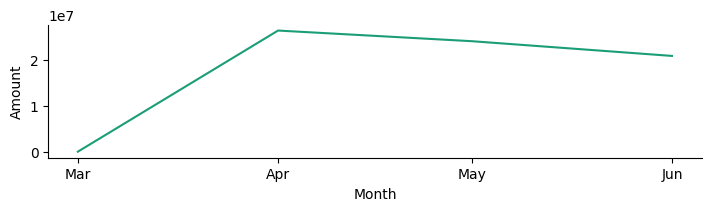

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Amount']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(7, 2), layout='constrained')
df_sorted = monthly_revenue.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)

# Format the x-axis to show month abbreviations
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xlabel('Month')
_ = plt.ylabel('Amount')

In [ ]:
# for x, y in zip(df_sorted['Date'], df_sorted['Amount']):
#    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom')
# plt.show()

***Identifying best-selling products and seasonal sales trends***

In [ ]:
top_skus = valid_orders.groupby('SKU').agg({"Qty": 'sum', 'Amount': 'sum'}).sort_values('Qty', ascending=False).head(10)
top_skus

,Qty,Amount
SKU,,
JNE3797-KR-L,628,456689.0
JNE3797-KR-M,533,388351.0
JNE3797-KR-S,486,357989.0
JNE3405-KR-L,452,181073.0
J0230-SKD-M,435,483611.0
J0230-SKD-S,394,440684.0
JNE3797-KR-XL,389,288490.0
JNE3405-KR-S,380,156016.0
JNE3797-KR-XS,360,266460.0


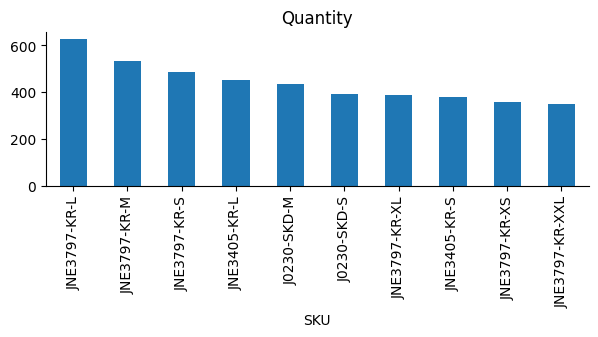

In [ ]:
top_skus['Qty'].plot(kind='bar', figsize=(7, 2), title='Quantity')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
top_categories = valid_orders.groupby('Category').agg({"Qty": 'sum', 'Amount': 'sum'}).sort_values('Qty', ascending=False).head(10)
top_categories

,Qty,Amount
Category,,
Set,42660,35480086.14
kurta,42466,19323092.48
Western Dress,13242,10079737.00
Top,9291,4868410.00
Ethnic Dress,1007,726357.00
Blouse,828,418402.00
Bottom,381,135396.00
Saree,147,114694.00
Dupatta,3,915.00


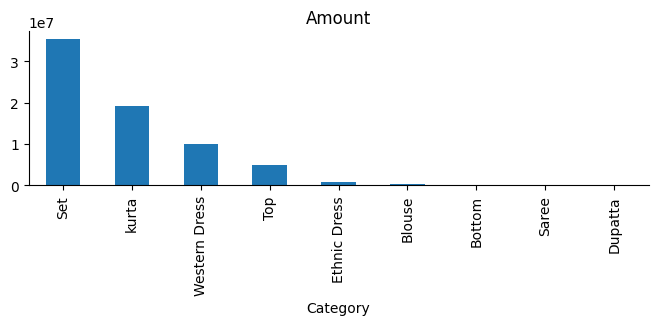

In [ ]:
top_categories['Amount'].plot(kind='bar', figsize=(8, 2), title='Amount')
plt.gca().spines[['top', 'right']].set_visible(False)

***Calculating the average order value to understand spending behavior.***

In [ ]:
total_revenue = valid_orders['Amount'].sum()
unique_orders = valid_orders['Order ID'].nunique()
aov = total_revenue / unique_orders

print(total_revenue)
print(unique_orders)
print(aov)

71147089.62
102304
695.4477793634658


**CUSTOMER INSIGHTS ANALYSIS**

***Identifying top-performing locations based on sales volume***

In [ ]:
top_states = (
    valid_orders.groupby('ship-state')
    .agg(Total_Quantity=('Qty', 'sum'), Total_Revenue=('Amount', 'sum'))
    .sort_values('Total_Quantity', ascending=False)
    .head(10)
)

top_cities = (
    valid_orders.groupby('ship-city')
    .agg(Total_Quantity=('Qty', 'sum'), Total_Revenue=('Amount', 'sum'))
    .sort_values('Total_Quantity', ascending=False)
    .head(10)
)

top_states, top_cities

(                Total_Quantity  Total_Revenue
 ship-state                                   
 MAHARASHTRA              19146    12134125.00
 KARNATAKA                15002     9561739.00
 TAMIL NADU                9861     5910256.00
 TELANGANA                 9649     6232919.57
 UTTAR PRADESH             8987     6130388.00
 DELHI                     5855     3876629.48
 KERALA                    5384     3352452.00
 WEST BENGAL               5044     3178992.00
 ANDHRA PRADESH            4512     2859102.00
 Gujarat                   3912     2525900.00,
            Total_Quantity  Total_Revenue
 ship-city                               
 BENGALURU            9855     6296528.00
 HYDERABAD            6877     4449797.57
 MUMBAI               5334     3375563.00
 NEW DELHI            4985     3303329.48
 CHENNAI              4655     2802203.00
 PUNE                 3345     2143680.00
 KOLKATA              2060     1291329.00
 GURUGRAM             1647     1127749.00
 THANE         

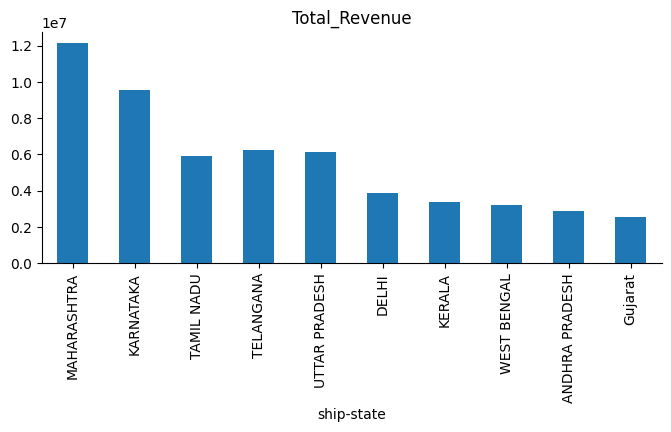

In [ ]:
top_states['Total_Revenue'].plot(kind='bar', figsize=(8, 3), title='Total_Revenue')
plt.gca().spines[['top', 'right']].set_visible(False)

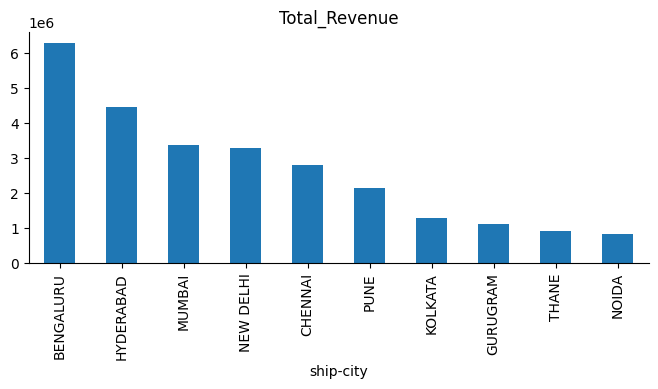

In [ ]:
top_cities['Total_Revenue'].plot(kind='bar', figsize=(8, 3), title='Total_Revenue')
plt.gca().spines[['top', 'right']].set_visible(False)

***Analyzing order cancellation trends and customer retention.***

In [ ]:
data['Month'] = data['Date'].dt.to_period('M')
cancelled_orders = data[data['Status'].str.contains("cancel", case=False, na=False)]
#cancellations_by_month
cancellations_by_month = cancelled_orders.groupby('Month').size().sort_index()
cancellations_by_month

,0
Month,
2022-03,18
2022-04,7139
2022-05,5881
2022-06,5303


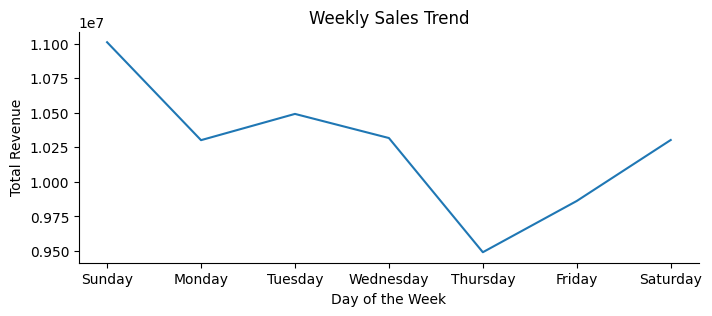

In [ ]:
weekly_sales = data.groupby(data['Date'].dt.day_name())['Amount'].sum()
weekly_sales = weekly_sales.reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
weekly_sales.plot(kind='line', figsize=(8, 3), title='Weekly Sales Trend')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [ ]:
# Cancellation rate
cancellation_rate = len(cancelled_orders) / len(data) * 100
cancellation_rate

14.223452682843604

In [ ]:
# Categories most prone to cancellations
cancelled_by_category = cancelled_orders['Category'].value_counts()
cancelled_by_category

,count
Category,
Set,7338
kurta,7259
Western Dress,2125
Top,1276
Ethnic Dress,146
Blouse,116
Bottom,60
Saree,21


In [ ]:
# Customer retention: reuse of ship-city + state
customer_orders = data.groupby(['ship-city', 'ship-state']).size()
repeat_customers = (customer_orders > 1).sum()
total_customers = len(customer_orders)
repeat_customer_rate = repeat_customers / total_customers * 100
repeat_customer_rate

np.float64(52.22999562745956)

***Differentiating B2B vs. B2C customer behavior for targeted marketing.***

In [ ]:
b2b_orders = data[data['B2B'] == True]
b2c_orders = data[data['B2B'] == False]

b2b_series = pd.Series({
    "Total Orders": b2b_orders['Order ID'].count(),
    "Total Revenue": b2b_orders['Amount'].sum(),
    "Total Quantity": b2b_orders['Qty'].sum(),
    "Average Order Value": b2b_orders['Amount'].mean(),
    "Average Quantity per Order": b2b_orders['Qty'].mean()
})

b2c_series = pd.Series({
    "Total Orders": b2c_orders['Order ID'].count(),
    "Total Revenue": b2c_orders['Amount'].sum(),
    "Total Quantity": b2c_orders['Qty'].sum(),
    "Average Order Value": b2c_orders['Amount'].mean(),
    "Average Quantity per Order": b2c_orders['Qty'].mean()
})

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({"B2B": b2b_series, "B2C": b2c_series})
comparison_df

,B2B,B2C
Total Orders,871.000000,1.280780e+05
Total Revenue,559945.000000,7.121500e+07
Total Quantity,841.000000,1.158100e+05
Average Order Value,642.876005,5.560284e+02
Average Quantity per Order,0.965557,9.042146e-01


**LOGISTICS & FULFILLMENT OPTIMIZATION**

***Addressing shipping delays by calculating average shipping times.***

In [ ]:
shipped_orders = data[
    data['Status'].str.contains("shipped", case=False, na=False) &
    data['Courier Status'].notna()
]

# Analyze courier status distribution
courier_status_counts = shipped_orders['Courier Status'].value_counts()
courier_status_counts

,count
Courier Status,
Shipped,109436
Unshipped,116
Cancelled,94


***Comparing orders fulfilled by Amazon vs. Merchant fulfillment.***

In [ ]:
# Compare fulfillment type with courier performance
fulfillment_courier = shipped_orders.groupby('Fulfilment')['Courier Status'].value_counts().unstack(fill_value=0)
fulfillment_courier

Courier Status,Cancelled,Shipped,Unshipped
Fulfilment,,,
Amazon,94,77567,116
Merchant,0,31869,0


***Improving order processing for faster deliveries***

In [ ]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format="%m-%d-%y", errors='coerce')

# Extract shipping timeline using 'Date' and infer delivery speed categories
# Since we don't have delivery timestamps, we’ll rely on 'ship-service-level'
shipping_speed = data[data['Status'].str.contains("shipped", case=False, na=False)]

# Average daily order volume per fulfillment type for process improvement insights
order_volume_by_fulfillment = (
    shipping_speed.groupby('Fulfilment')
    .resample('D', on='Date')
    .size()
    .groupby('Fulfilment')
    .mean()
)

# Distribution of ship service levels
service_level_dist = shipping_speed['ship-service-level'].value_counts()

order_volume_by_fulfillment, service_level_dist

(Fulfilment
 Amazon      854.692308
 Merchant    358.247191
 dtype: float64,
 ship-service-level
 Expedited    76752
 Standard     32909
 Name: count, dtype: int64)

*   Optimize Standard Shipping Offers
*   Leverage Amazon Fulfillment for High-Volume SKUs
*   Investigate Unshipped Amazon Orders
*   Monitor Daily Merchant capacity








**PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION**

***Identifying high-demand product categories.***

In [ ]:
category_summary = data.groupby('Category').agg(
    Total_Quantity_Sold=('Qty', 'sum'),
    Total_Orders=('Order ID', 'count')
).sort_values(by='Total_Quantity_Sold', ascending=False)

category_summary

,Total_Quantity_Sold,Total_Orders
Category,,
Set,45288,50275
kurta,45049,49867
Western Dress,13943,15495
Top,9902,10621
Ethnic Dress,1052,1158
Blouse,864,926
Bottom,398,440
Saree,152,164
Dupatta,3,3


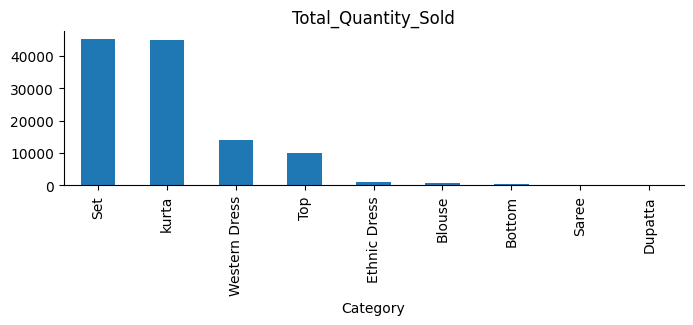

In [ ]:
category_summary['Total_Quantity_Sold'].plot(kind='bar', figsize=(8, 2), title='Total_Quantity_Sold')
plt.gca().spines[['top', 'right']].set_visible(False)

***Analyzing the average quantity ordered for efficient stock management.***

In [ ]:
Average_Qty_Per_Order = data.groupby('Category').agg(
    Total_Orders=('Order ID', 'count'),
    Average=('Qty', 'mean')
).sort_values(by='Total_Orders', ascending=False)
Average_Qty_Per_Order

,Total_Orders,Average
Category,,
Set,50275,0.900806
kurta,49867,0.903383
Western Dress,15495,0.899839
Top,10621,0.932304
Ethnic Dress,1158,0.908463
Blouse,926,0.933045
Bottom,440,0.904545
Saree,164,0.926829
Dupatta,3,1.000000


***Enhancing inventory control to prevent stockouts or overstocking.***

1.Critical Stock Categories:

*   Set and Kurta: Require active inventory monitoring due to high demand.
*   Consider dynamic restocking (weekly/monthly) based on rolling average sales.

2.Low Velocity / Overstock Risk:

*   Dupatta, Saree, Bottom: Low order count and volume. Optimize stocking and avoid bulk replenishment.

3.Stocking Strategy:

*   Maintain a "min-max" stock level policy using historical average quantity and sales velocity.
*   Example: If Kurtas sell ~1 per order, and 45,000 units were sold in total, keep safety stock based on peak season sales rate.



**CUSTOMER SATISFACTION & RETURNS**

***Investigating high return and cancellation rates.***

In [ ]:
category_summary = data.groupby('Category').agg(
    Total_Quantity_Sold=('Qty', 'sum'),
    Total_Orders=('Order ID', 'count'),
    Average_Qty_Per_Order=('Qty', 'mean')
).sort_values(by='Total_Quantity_Sold', ascending=False)

In [ ]:
# Normalize status column for analysis
data['Status'] = data['Status'].str.lower()

# Flag cancellations and returns
data['is_cancelled'] = data['Status'].str.contains("cancel", na=False)
data['is_returned'] = data['Status'].str.contains("return", na=False)

# Group by product category
category_issues = data.groupby('Category').agg(
    Total_Orders=('Order ID', 'count'),
    Cancelled_Orders=('is_cancelled', 'sum'),
    Returned_Orders=('is_returned', 'sum')
)

# Calculate cancellation and return rates
category_issues['Cancellation Rate (%)'] = (category_issues['Cancelled_Orders'] / category_issues['Total_Orders']) * 100
category_issues['Return Rate (%)'] = (category_issues['Returned_Orders'] / category_issues['Total_Orders']) * 100

# Sort by highest combined issue rate
category_issues['Total Issue Rate (%)'] = category_issues['Cancellation Rate (%)'] + category_issues['Return Rate (%)']
category_issues_sorted = category_issues.sort_values(by='Total Issue Rate (%)', ascending=False)

category_issues_sorted

,Total_Orders,Cancelled_Orders,Returned_Orders,Cancellation Rate (%),Return Rate (%),Total Issue Rate (%)
Category,,,,,,
Set,50275,7338,839,14.595724,1.668821,16.264545
kurta,49867,7259,750,14.556721,1.504001,16.060722
Western Dress,15495,2125,342,13.714101,2.207164,15.921265
Bottom,440,60,6,13.636364,1.363636,15.000000
Ethnic Dress,1158,146,16,12.607945,1.381693,13.989637
Blouse,926,116,12,12.526998,1.295896,13.822894
Saree,164,21,1,12.804878,0.609756,13.414634
Top,10621,1276,132,12.013935,1.242821,13.256755
Dupatta,3,0,0,0.000000,0.000000,0.000000


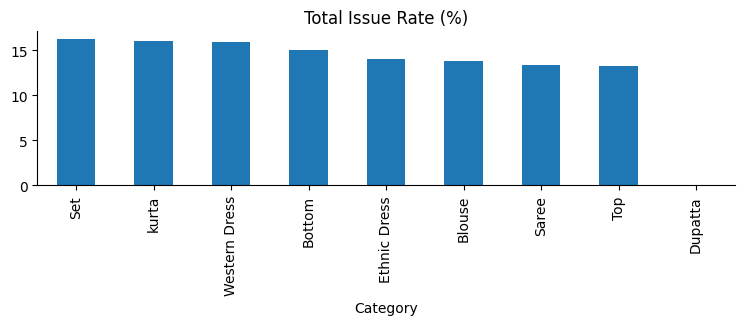

In [ ]:
category_issues_sorted['Total Issue Rate (%)'].plot(kind='bar', figsize=(9, 2), title='Total Issue Rate (%)')
plt.gca().spines[['top', 'right']].set_visible(False)

***Identifying problematic products/categories to enhance quality.***

**Set**, **Kurta**, **Western Dress**, **Bottom** are the most problematic categories each with 15 - 16% Issue Rate

***Improving customer experience through better service policies.***

1. **Product Quality Checks**

  *   High returns indicate possible fit/size issues or misleading photos/
  descriptions.
  *   Prioritize QC for Sets, Kurtas, and Western Dresses.
2.   **Size & Fit Guidance**

  *   Include detailed size charts, model sizing references, and customer feedback summaries on product pages.

3.   **Flexible Cancellation/Return Windows**

  *   Early cancellations may be due to buyer’s remorse or unclear shipping expectations.
  *   Consider adding "cancel within 1 hour" button to reduce downstream fulfillment waste.

4.   **Enhanced Product Descriptions**

  *   For top-cancelled SKUs, review and revise product titles, images, fabric info, and return policy visibility.














**RECOMMENDATIONS**

Based on the analysis, here are some recommendations:

1.  **Address High Cancellation/Return Rates in Key Categories:** Focus on improving product quality, providing detailed size and fit information, and potentially refining product descriptions for "Set", "Kurta", "Western Dress", and "Bottom" categories, as they show the highest issue rates.
2.  **Optimize Inventory for High-Demand Categories:** Implement dynamic restocking strategies for "Set" and "Kurta" based on sales velocity to prevent stockouts. For low-velocity items like "Dupatta", "Saree", and "Bottom", optimize stocking to avoid overstocking.
3.  **Investigate Unshipped Amazon Orders:** The analysis shows a number of unshipped orders fulfilled by Amazon. Investigate the reasons behind these to improve fulfillment efficiency.
4.  **Leverage Amazon Fulfillment for High-Volume SKUs:** Given the higher average daily order volume handled by Amazon fulfillment, consider leveraging this for high-volume SKUs.
5.  **Monitor Daily Merchant Capacity:** The analysis shows a lower average daily order volume for merchant fulfilled orders. Monitor merchant capacity to ensure they can handle potential increases in order volume.
6.  **Analyze Weekly Sales Trends:** Use the weekly sales trend analysis to optimize staffing and inventory levels for peak days.
7.  **Targeted Marketing for B2B vs. B2C:** Utilize the insights from the B2B vs. B2C analysis to tailor marketing campaigns and product offerings to each customer segment.

In [ ]:
data.Amount.median()

545.0

**CONCLUSION**

Based on the comprehensive analysis of the sales data, several key insights have been identified across various aspects of the business:

**Financial Performance:**

*   Revenue shows a strong trend, with a significant peak in April 2022, followed by a slight decrease in subsequent months. Further investigation into the factors contributing to the April peak and the subsequent decline could inform strategies for stabilizing and increasing revenue.
*   The average order value provides a baseline for understanding customer spending behavior and can be used to track the impact of promotions and product bundling.

**Product Management & Inventory:**

*   "Set" and "Kurta" categories are the top performers in terms of both quantity sold and total orders, indicating high demand. These categories require careful inventory management to avoid stockouts.
*   "Dupatta," "Saree," and "Bottom" categories have significantly lower sales volume and order counts, suggesting a need to optimize stocking strategies to prevent overstocking and minimize holding costs.
*   The average quantity per order is consistently around 1 across all categories, which simplifies inventory forecasting.

**Customer Insights:**

*   Maharashtra, Karnataka, and Tamil Nadu are the top-performing states in terms of both quantity and revenue, highlighting key markets for targeted marketing and sales efforts.
*   Bengaluru, Hyderabad, and Mumbai are the top cities, further refining the focus areas for regional strategies.
*   The analysis of B2B vs. B2C orders reveals differences in order volume, revenue, and average order value, suggesting the need for tailored approaches to engage each customer segment.

**Customer Satisfaction & Returns:**

*   "Set," "Kurta," "Western Dress," and "Bottom" categories have the highest total issue rates (cancellations and returns), indicating potential areas for improvement in product quality, sizing, or descriptions.
*   The overall cancellation rate is significant, emphasizing the importance of addressing the root causes of cancellations to improve customer satisfaction and reduce lost revenue.
*   A substantial percentage of customers have placed repeat orders (based on ship-to location), suggesting a good level of customer retention, which can be further enhanced by addressing product issues and improving service.

**Logistics & Fulfillment:**

*   Amazon fulfillment handles a significantly higher average daily order volume compared to merchant fulfillment. Leveraging Amazon fulfillment for high-volume SKUs could improve efficiency.
*   The presence of unshipped orders fulfilled by Amazon warrants investigation to identify and resolve any bottlenecks in the fulfillment process.

**Recommendations:**

Based on these findings, the recommendations outlined previously (in the markdown cell above this one) provide actionable steps to address the identified areas for improvement and capitalize on opportunities for growth.

Based on the analysis of the sales dataset, it's not possible to determine the company's background. The dataset contains information about sales orders, products, customers, and logistics, but it doesn't include details about the company's history, mission, or other background information. You would need to consult external sources or internal company documents to analyze the company's background.

Based on the information you provided about the e-commerce company, here is a more detailed explanation of its background and operational context:

1.  **Facing Operational Challenges:** The company is currently struggling with various issues in its day-to-day operations. These challenges could include inefficiencies in areas like inventory management, order processing, shipping, or handling returns. These operational bottlenecks are likely impacting the company's ability to grow smoothly and meet customer expectations.

2.  **Hindering Growth and Customer Satisfaction:** The operational challenges are having a direct negative impact on key business metrics. Growth might be stunted due to delays, errors, or inability to scale effectively. Customer satisfaction is likely low due to issues like late deliveries, incorrect orders, or a difficult returns process.

3.  **Leveraging Data-Driven Insights:** To combat these problems, the company is adopting a data-driven approach. This means they are collecting and analyzing data from their operations (like the sales dataset you've been working with) to understand the root causes of their challenges.

4.  **Optimizing Operations:** The ultimate goal of using data is to optimize their operations. By identifying inefficiencies and areas for improvement through data analysis, the company aims to streamline processes, reduce errors, speed up delivery times, and improve overall efficiency. This optimization is crucial for overcoming the growth barriers and enhancing customer satisfaction.

5.  **Strategic Shift Towards Data:** This indicates a strategic decision by the company to move towards a more analytical and informed way of running the business. By relying on data rather than intuition or traditional methods, they are positioning themselves to make better decisions and build a more resilient and customer-focused operation.

**CHALLENGES**

During this project, I encountered a few challenges:

1.  **Data Cleaning and Handling Missing Values:** The dataset had missing values in several columns (`Courier Status`, `currency`, `Amount`, `ship-city`, `ship-state`, `ship-postal-code`, `ship-country`, `promotion-ids`, `fulfilled-by`, `Unnamed: 22`). Deciding how to handle these missing values (e.g., imputation, dropping rows/columns) was a critical step to ensure the accuracy of the analysis.
2.  **Data Type Conversion:** The 'Date' column was initially an object type. Converting it to a datetime object was necessary for time-series analysis, and handling potential errors during conversion (as seen with `errors='coerce'`) was important.
3.  **Defining "Valid Orders":** The analysis focused on "shipped" orders, but the 'Status' column had variations like "Shipped - Delivered to Buyer". Ensuring the correct filtering to capture all relevant shipped orders was crucial for accurate financial and logistical analysis.
4.  **Categorizing and Grouping Data:** Grouping data by categories, states, cities, and fulfillment types was fundamental to the analysis. Ensuring consistent categorization and handling potential inconsistencies in the data was necessary for meaningful insights.
5.  **Interpreting Business Metrics:** Translating the results of data analysis into actionable business recommendations required understanding the context of an e-commerce business and how metrics like cancellation rates, average order value, and fulfillment performance relate to operational challenges and growth.
6.  **Limited Scope of Data:** The dataset provided a snapshot of sales data. A more comprehensive analysis would benefit from additional data sources, such as customer demographics, marketing spend, website traffic, and customer feedback, which were not available in this dataset. This limited the ability to draw more in-depth conclusions about customer behavior and the broader market context.